In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

df_geral = pd.read_csv("data/ProuniRelatorioDadosAbertos2020.csv", sep=';', encoding="latin1")
df_pe = df_geral[df_geral["UF_BENEFICIARIO"] == 'PE']

#display(df_pe.shape)
#display(df_pe.info())
#display(df_pe.isna().sum())

colunas = [#"NOME_IES_BOLSA",
           "TIPO_BOLSA",
           "MODALIDADE_ENSINO_BOLSA",
           #"NOME_CURSO_BOLSA",
           "NOME_TURNO_CURSO_BOLSA",
           #"CPF_BENEFICIARIO",
           "SEXO_BENEFICIARIO",
           "RACA_BENEFICIARIO",
           "DATA_NASCIMENTO",
           "BENEFICIARIO_DEFICIENTE_FISICO",
           "MUNICIPIO_BENEFICIARIO"]

df_pe = df_pe.dropna(subset=colunas)

df_pe_analisado = df_pe[colunas]
df_pe_analisado["DATA_NASCIMENTO"] = pd.to_datetime(df_pe_analisado["DATA_NASCIMENTO"], format="%d/%m/%Y")
df_pe_analisado = df_pe_analisado.sort_values(by = "DATA_NASCIMENTO")
df_pe_analisado = df_pe_analisado.reset_index(drop=True)

series_pe_municipios = df_pe_analisado["MUNICIPIO_BENEFICIARIO"].value_counts()
df_pe_municipios = series_pe_municipios.reset_index()
df_pe_municipios.columns = ["MUNICIPIOS", "TOTAL"]

#display(df_pe)
display(df_pe_analisado)
display(df_pe_municipios)

,TIPO_BOLSA,MODALIDADE_ENSINO_BOLSA,NOME_TURNO_CURSO_BOLSA,SEXO_BENEFICIARIO,RACA_BENEFICIARIO,DATA_NASCIMENTO,BENEFICIARIO_DEFICIENTE_FISICO,MUNICIPIO_BENEFICIARIO
0,INTEGRAL,EAD,CURSO A DISTÂNCIA,M,Branca,1950-07-28,S,VITORIA DE SANTO ANTAO
1,INTEGRAL,EAD,CURSO A DISTÂNCIA,M,Parda,1956-07-08,N,RECIFE
2,INTEGRAL,PRESENCIAL,NOTURNO,M,Parda,1957-01-01,N,RECIFE
3,INTEGRAL,EAD,CURSO A DISTÂNCIA,F,Branca,1958-02-10,N,RECIFE
4,INTEGRAL,EAD,CURSO A DISTÂNCIA,M,Preta,1961-02-20,N,RECIFE
...,...,...,...,...,...,...,...,...
6705,INTEGRAL,PRESENCIAL,NOTURNO,F,Branca,2003-10-09,N,IGARASSU
6706,PARCIAL,PRESENCIAL,MATUTINO,F,Parda,2003-10-24,N,SERRITA
6707,INTEGRAL,PRESENCIAL,MATUTINO,F,Branca,2003-11-13,N,BARRA DE GUABIRABA
6708,INTEGRAL,PRESENCIAL,NOTURNO,F,Branca,2004-02-11,N,AGUA PRETA


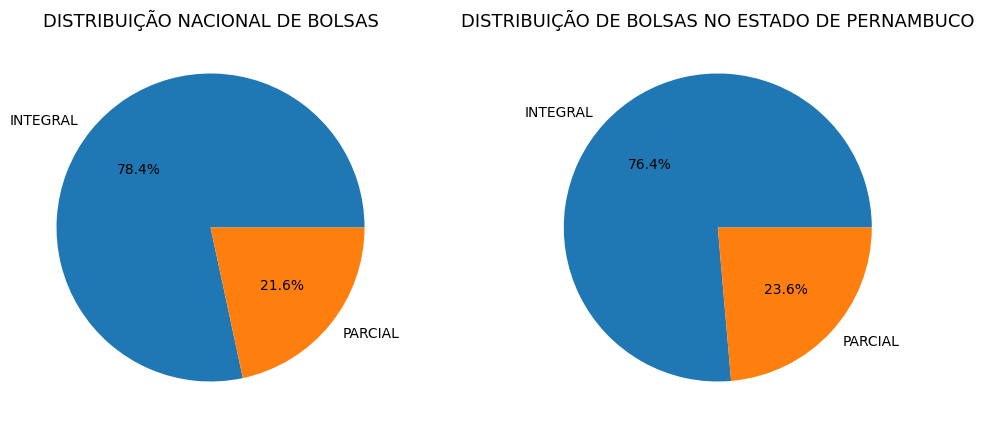

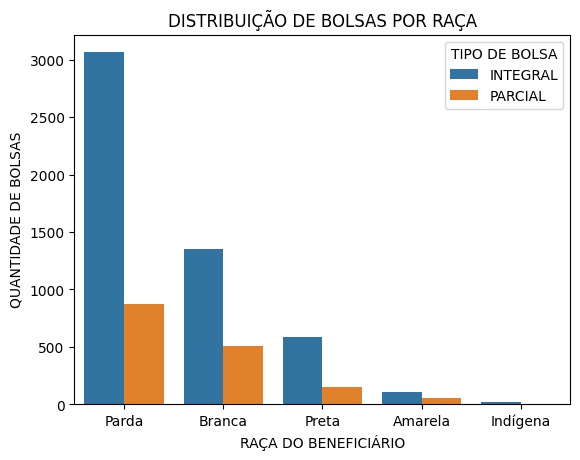

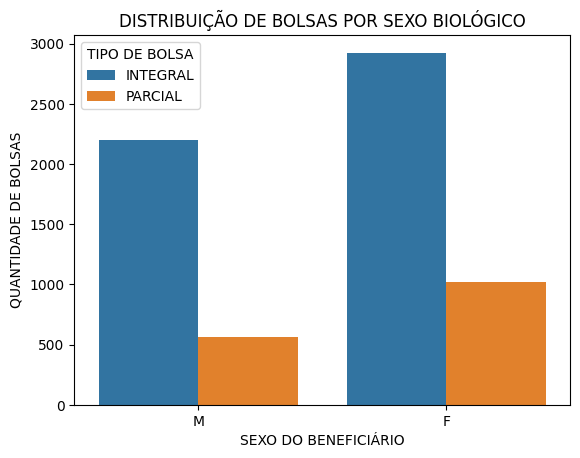

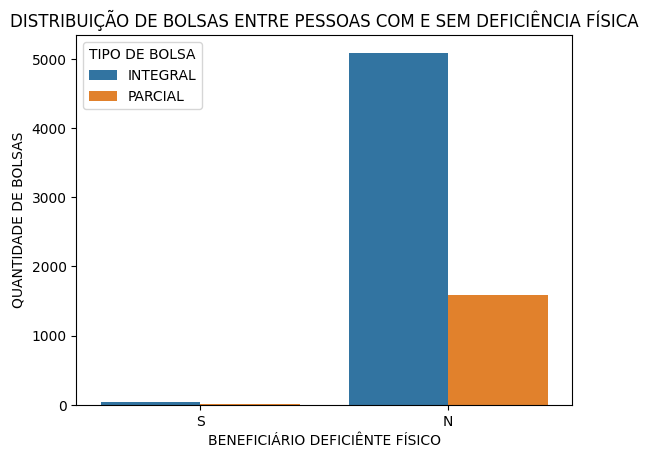

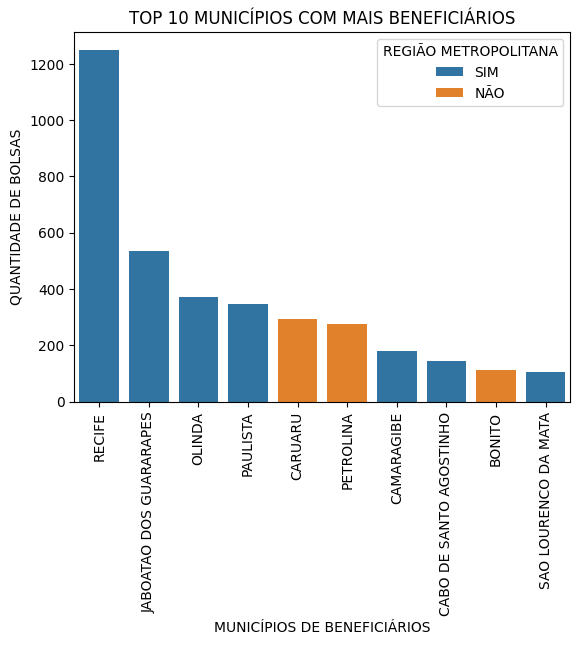

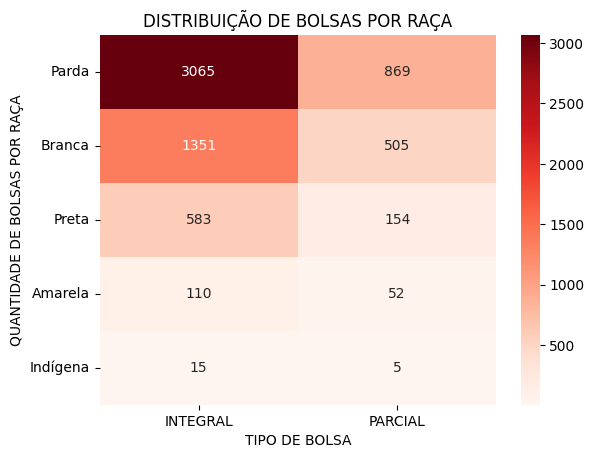

In [ ]:
#distribuição de bolsas no Brasil e no estado de Pernambuco
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

df_geral["TIPO_BOLSA"].value_counts().plot.pie(
    autopct="%1.1f%%",
    ax = ax1
)
ax1.set_title("DISTRIBUIÇÃO NACIONAL DE BOLSAS", fontsize=13)

df_pe_analisado["TIPO_BOLSA"].value_counts().plot.pie(
    autopct="%1.1f%%",
    ax = ax2
)
ax2.set_title("DISTRIBUIÇÃO DE BOLSAS NO ESTADO DE PERNAMBUCO", fontsize=13)

plt.show()

#distribuição de bolsas por perfil étnico-racial    
df_pe_analisado["RACA_BENEFICIARIO"] = df_pe_analisado["RACA_BENEFICIARIO"].replace('Ind¡gena', 'Indígena')
#display(df_pe_analisado["RACA_BENEFICIARIO"].unique())
ordem_perfis = ["Parda", "Branca", "Preta", "Amarela", "Indígena"]

sns.countplot(
    data = df_pe_analisado,
    x = "RACA_BENEFICIARIO",
    hue = "TIPO_BOLSA",
    order = ordem_perfis
)
plt.title("DISTRIBUIÇÃO DE BOLSAS POR PERFIL ÉTNICO-RACIAL")
plt.xlabel("PERFIL ÉTNICO-RACIAL DO BENEFICIÁRIO")
plt.ylabel("QUANTIDADE DE BOLSAS")
plt.legend(title="TIPO DE BOLSA")

plt.show()

#distribuição de bolsas por sexo do beneficiário
sns.countplot (
    data = df_pe_analisado,
    x = "SEXO_BENEFICIARIO",
    hue = "TIPO_BOLSA"
)
plt.title("DISTRIBUIÇÃO DE BOLSAS POR SEXO")
plt.xlabel("SEXO DO BENEFICIÁRIO")
plt.ylabel("QUANTIDADE DE BOLSAS")
plt.legend(title="TIPO DE BOLSA")

plt.show()

#distribuição de bolsas para deficiêntes físicos
sns.countplot(
    data = df_pe_analisado,
    x = "BENEFICIARIO_DEFICIENTE_FISICO",
    hue = "TIPO_BOLSA"
)
plt.title("DISTRIBUIÇÃO DE BOLSAS ENTRE PESSOAS COM E SEM DEFICIÊNCIA FÍSICA")
plt.xlabel("BENEFICIÁRIO DEFICIÊNTE FÍSICO")
plt.ylabel("QUANTIDADE DE BOLSAS")
plt.legend(title="TIPO DE BOLSA")

plt.show()

#distribuição de bolsas entre os top10 municípios de Pernambuco
df_pe_top_municipios = df_pe_municipios.head(10)

regiao_metropolitana = ["RECIFE",
                        "JABOATAO DOS GUARARAPES",
                        "OLINDA",
                        "PAULISTA",
                        "CABO DE SANTO AGOSTINHO",
                        "CAMARAGIBE",
                        "IGARASSU",
                        "SAO LOURENCO DA MATA",
                        "ABREU E LIMA",
                        "IPOJUCA",
                        "MORENO",
                        "ITAPISSUMA",
                        "ARAÇOIABA",
                        "ILHA DE ITAMARACA"]

df_pe_top_municipios["REGIÃO METROPOLITANA"] = np.where(df_pe_top_municipios["MUNICIPIOS"].isin(regiao_metropolitana), "SIM", "NÃO")

sns.barplot(
    data = df_pe_top_municipios,
    x = "MUNICIPIOS",
    y = "TOTAL",
    hue= "REGIÃO METROPOLITANA"
)
plt.title("TOP 10 MUNICÍPIOS COM MAIS BENEFICIÁRIOS")
plt.xlabel("MUNICÍPIOS DE BENEFICIÁRIOS")
plt.xticks(rotation=90)
plt.ylabel("QUANTIDADE DE BOLSAS")

plt.show()

#(teste) heatmap da distribuição de bolsas por perfil étnico-racial 
tabela = pd.crosstab(
    df_pe_analisado["RACA_BENEFICIARIO"],
    df_pe_analisado["TIPO_BOLSA"]
)

tabela = tabela.reindex(ordem_perfis)

sns.heatmap(
    tabela,
    annot=True,
    fmt="d",
    cmap="Reds"
)
plt.title("DISTRIBUIÇÃO DE BOLSAS POR RAÇA")
plt.xlabel("TIPO DE BOLSA")
plt.ylabel("QUANTIDADE DE BOLSAS POR RAÇA")
plt.yticks(rotation=0)

plt.show()

In [ ]:
#preparando os dados para o mapa
mapa_pe = gpd.read_file("mapa/PE_Municipios_2025.shp")

mapa_pe["municipio_norm"] = (
    mapa_pe["NM_MUN"]
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.upper()
    .str.strip()
)
    
df_pe_municipios["municipio_norm"] = (
    df_pe_municipios["MUNICIPIOS"]
    .str.strip()
)

mapa_dados = mapa_pe.merge(
    df_pe_municipios,
    how="left",
    on="municipio_norm"
)

mapa_dados["TOTAL"] = mapa_dados["TOTAL"].fillna(0)

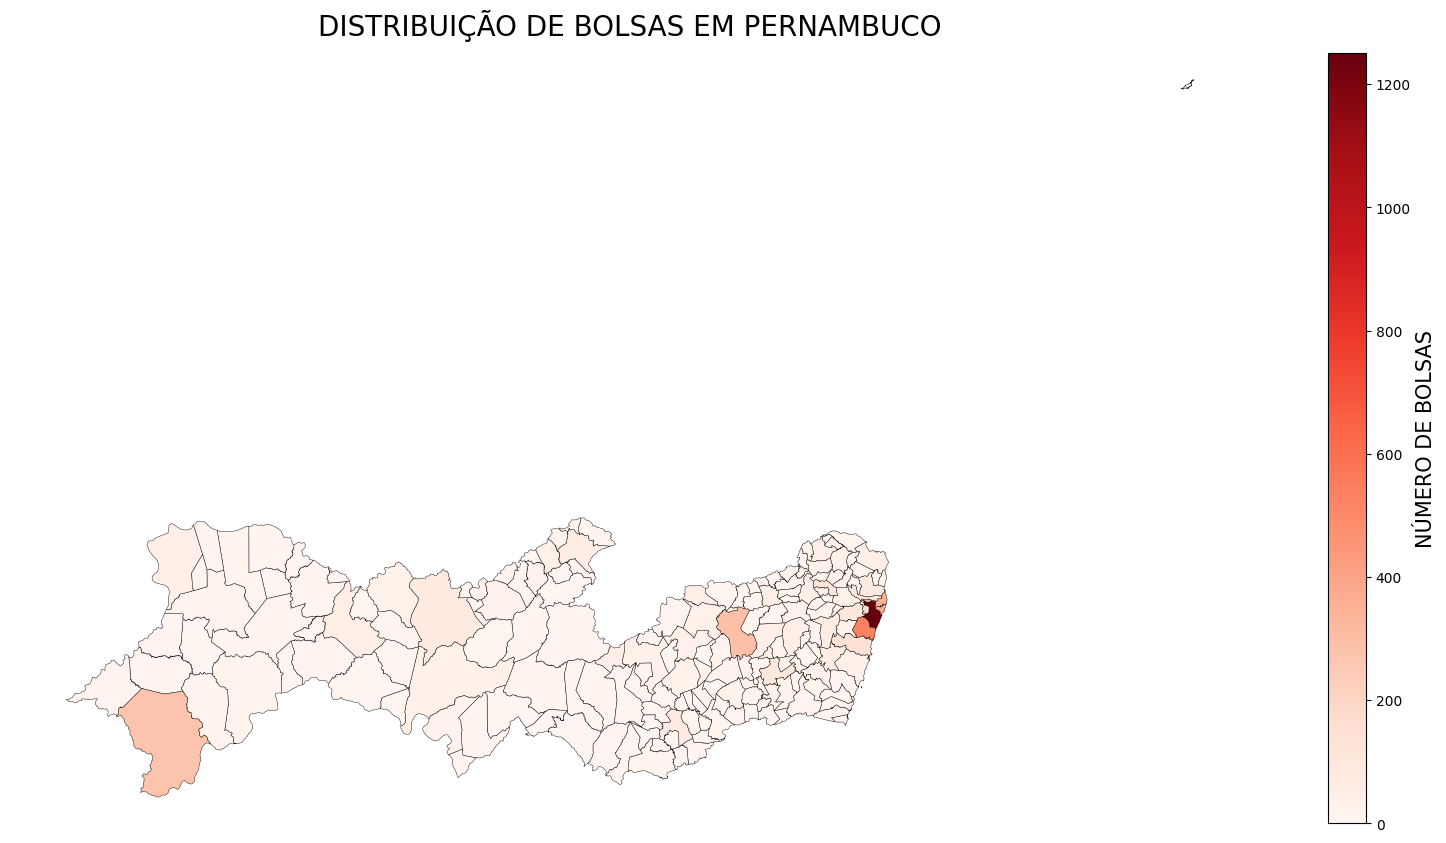

In [ ]:
#plotando o mapa
fig, ax = plt.subplots(figsize=(20, 20))

mapa_dados.plot(
    column="TOTAL",
    cmap="Reds",
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

vmin=mapa_dados["TOTAL"].min()
vmax=mapa_dados["TOTAL"].max()
norm = plt.Normalize(vmin = vmin, vmax = vmax)

sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)

cbar = fig.colorbar(
    sm,
    shrink=0.5,
    ax=ax,
)
cbar.set_label("NÚMERO DE BOLSAS", fontsize=15)

ax.axis("off")
ax.set_title("DISTRIBUIÇÃO DE BOLSAS EM PERNAMBUCO", fontsize=20)

plt.show()